In [1]:
# eda04: chain registration transforms, register all exposures to reference (shortest), weighted merge
import math
import numpy as np
import torch
import pickle
import tqdm
from pathlib import Path
from PIL import Image
import enum
from dataclasses import dataclass

class MoonInfoOrigin(enum.Enum):
    DIRECT = 0
    INTERPOLATED = 1

@dataclass
class ImageInfo:
    path: Path
    width: int
    height: int
    avg_brightness: float
    timestamp: float
    exposure_time: float
    moon: tuple[float, float, float] = None
    moon_info_origin: MoonInfoOrigin = None
    moon_pos_std_px: float = None

PKL_DIR = "/home/slavik/tmp"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load eda02 (exposure_groups, opt_results) and eda03 (cross_reg, gamma_by_pair)
with open(f"{PKL_DIR}/eda02.pkl", "rb") as fd:
    exposure_groups = pickle.load(fd)
    reg = pickle.load(fd)
    opt_results = pickle.load(fd)
with open(f"{PKL_DIR}/eda03.pkl", "rb") as fd:
    cross_reg = pickle.load(fd)
    gamma_by_pair = pickle.load(fd)

exposure_times_sorted = sorted(exposure_groups.keys())
# Reference = first (shortest) exposure
t_ref = exposure_times_sorted[0]

def moon_median(group):
    centers_i = [ii.moon[0] for ii in group]
    centers_j = [ii.moon[1] for ii in group]
    radii = [ii.moon[2] for ii in group]
    return (float(np.median(centers_i)), float(np.median(centers_j)), float(np.median(radii)))

moon_ref = moon_median(exposure_groups[t_ref])
print(f"Reference exposure t_ref={t_ref}, moon_ref (i,j,r)={moon_ref}")
print(f"cross_reg pairs: {len(cross_reg)}, gamma_by_pair: {len(gamma_by_pair)}")

Reference exposure t_ref=0.00025, moon_ref (i,j,r)=(1975.8032373889234, 2872.06197001884, 316.0698799244132)
cross_reg pairs: 16, gamma_by_pair: 16


In [2]:
# Recompute per-exposure averaged images (same logic as eda03; not saved there)
def load_grayscale(ii, device):
    with Image.open(ii.path) as img:
        arr = np.array(img).astype(np.float32) / 255.0
    if arr.ndim == 3:
        arr = arr.mean(axis=2)
    return torch.from_numpy(arr).to(device=device, dtype=torch.float32)

def apply_transform_single(img, shift_i, shift_j, angle_deg, device):
    H, W = img.shape
    ci, cj = H / 2.0, W / 2.0
    angle_rad = math.radians(-angle_deg)
    cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    di = ii - ci - shift_i
    dj = jj - cj - shift_j
    i_src = di * cos_a + dj * sin_a + ci
    j_src = -di * sin_a + dj * cos_a + cj
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

def compute_weighted_average(group, abs_xy, abs_angle_t, device, epsilon=1e-6):
    n = len(group)
    sum_img = None
    sum_mask = None
    for j in range(n):
        img_j = load_grayscale(group[j], device)
        mj_i, mj_j, r_j = group[j].moon[0], group[j].moon[1], group[j].moon[2]
        H, W = img_j.shape
        ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
        jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
        dist = torch.sqrt((ii - mj_i) ** 2 + (jj - mj_j) ** 2)
        # Fill moon with black (radius = moon radius + 2) in this image before warping
        img_j = img_j.clone()
        mask_j = (dist > r_j + 2.0).to(torch.float32)
        x_j = float(abs_xy[j, 0])
        y_j = float(abs_xy[j, 1])
        theta_j_deg = -math.degrees(float(abs_angle_t[j]))
        w_img = apply_transform_single(img_j, x_j, y_j, theta_j_deg, device)
        w_mask = apply_transform_single(mask_j, x_j, y_j, theta_j_deg, device)
        if sum_img is None:
            sum_img = w_img * w_mask
            sum_mask = w_mask.clone()
        else:
            sum_img = sum_img + w_img * w_mask
            sum_mask = sum_mask + w_mask
    avg_img = sum_img / (sum_mask + epsilon)
    avg_mask = sum_mask / n
    return avg_img, avg_mask

avg_images = {}
avg_masks = {}
for exp in tqdm.tqdm(exposure_times_sorted, desc="Averaged images"):
    group = exposure_groups[exp]
    if exp not in opt_results or len(group) < 2:
        continue
    abs_xy = torch.from_numpy(opt_results[exp]["abs_xy"]).to(device)
    abs_angle_t = torch.from_numpy(opt_results[exp]["abs_angle_t"]).to(device)
    avg_images[exp], avg_masks[exp] = compute_weighted_average(group, abs_xy, abs_angle_t, device)

print(f"Built {len(avg_images)} averaged images.")
H_ref, W_ref = next(iter(avg_images.values())).shape
print(f"Reference shape H={H_ref}, W={W_ref}")

Averaged images: 100%|██████████| 17/17 [00:28<00:00,  1.67s/it]

Built 17 averaged images.
Reference shape H=4000, W=6000


In [3]:
# Build ref->k sampling grid by chaining pairwise transforms; scale factor to ref intensity
def ref_to_source_grid(H, W, chain_tuples, device):
    """chain_tuples: list of (shift_i, shift_j, rotation_deg) for (t0,t1), (t1,t2), ..."""
    ci, cj = H / 2.0, W / 2.0
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    i_cur = ii.clone()
    j_cur = jj.clone()
    for (shift_i, shift_j, rotation_deg) in chain_tuples:
        angle_rad = math.radians(-rotation_deg)
        cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
        di = i_cur - ci - shift_i
        dj = j_cur - cj - shift_j
        i_cur = di * cos_a + dj * sin_a + ci
        j_cur = -di * sin_a + dj * cos_a + cj
    return i_cur, j_cur

def grid_to_normalized_grid(i_src, j_src, H, W):
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    return torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)

def warp_to_ref(img, chain_tuples, H_ref, W_ref, device):
    """Warp img (same or larger concept size) to reference grid using chain ref->source."""
    i_src, j_src = ref_to_source_grid(H_ref, W_ref, chain_tuples, device)
    grid = grid_to_normalized_grid(i_src, j_src, img.shape[0], img.shape[1])
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

# Scale factor to bring exposure t_k value to t_ref scale: value_ref = value_k * scale_k
# scale_k = (t_ref/t_1)^(1/g1) * (t_1/t_2)^(1/g2) * ... * (t_{k-1}/t_k)^(1/g_k)
def scale_to_ref(exposure_times_sorted, gamma_by_pair, k):
    if k == 0:
        return 1.0
    scale = 1.0
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in gamma_by_pair:
            return None
        g = gamma_by_pair[(t0, t1)]
        scale *= (t0 / t1) ** (1.0 / g)
    return scale

# Exposures that have both avg_image and a chain from ref (consecutive pairs present)
exposures_with_chain = [t_ref]
chain_tuples_by_exp = {t_ref: []}  # ref -> ref is identity
for k in range(1, len(exposure_times_sorted)):
    t_k = exposure_times_sorted[k]
    if t_k not in avg_images:
        continue
    chain = []
    valid = True
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in cross_reg:
            valid = False
            break
        chain.append(cross_reg[(t0, t1)])
    if not valid:
        continue
    chain_tuples_by_exp[t_k] = chain
    exposures_with_chain.append(t_k)

print(f"Exposures in chain: {len(exposures_with_chain)}")

Exposures in chain: 17


In [4]:
# Weight from original (untransformed) value: exp(-((y-0.5)/0.1)^2), y clipped to [0,1]
WEIGHT_SIGMA = 0.2

def weight_from_value(y):
    y = np.clip(y, 0.0, 1.0).astype(np.float64)
    return np.exp(-((y - 0.5) / WEIGHT_SIGMA) ** 2)

# Accumulate weighted average in float64; track valid per exposure for crop
sum_val = np.zeros((H_ref, W_ref), dtype=np.float64)
sum_weight = np.zeros((H_ref, W_ref), dtype=np.float64)
valid_all = None  # intersection of warped valid masks (float, 1 where all exposures cover)
mask_0 = avg_masks[min(avg_masks.keys())] > 0.99
for t_k in tqdm.tqdm(exposures_with_chain, desc="Warp and merge"):
    img_k = avg_images[t_k]
    mask_k = avg_masks[t_k]
    chain = chain_tuples_by_exp[t_k]
    k_idx = exposure_times_sorted.index(t_k)
    scale_k = scale_to_ref(exposure_times_sorted, gamma_by_pair, k_idx)
    if scale_k is None:
        continue

    # Original (unscaled) and scaled value, clipped to [0,1]
    orig = img_k.cpu().numpy().astype(np.float64)
    orig_clip = np.clip(orig, 0.0, 1.0)
    value_scaled = np.clip(orig * scale_k, 0.0, 1.0)
    weight_img = weight_from_value(orig_clip)
    if k_idx > 0:
        weight_img *= (mask_k > 0.99).detach().cpu().numpy()

    # Warp to reference grid
    val_t = torch.from_numpy(value_scaled.astype(np.float32)).to(device)
    w_t = torch.from_numpy(weight_img.astype(np.float32)).to(device)
    valid_t = torch.ones_like(img_k, device=device, dtype=torch.float32)
    warped_val = (warp_to_ref(val_t, chain, H_ref, W_ref, device) * mask_0).cpu().numpy().astype(np.float64)
    warped_w = warp_to_ref(w_t, chain, H_ref, W_ref, device).cpu().numpy().astype(np.float64)
    warped_valid = warp_to_ref(valid_t, chain, H_ref, W_ref, device).cpu().numpy()

    # Only count where this exposure actually covers (avoid border pull-down)
    use = warped_valid >= 0.5
    sum_val += np.where(use, warped_val * warped_w, 0.0)
    sum_weight += np.where(use, warped_w, 0.0)

    if valid_all is None:
        valid_all = warped_valid.copy()
    else:
        valid_all = np.minimum(valid_all, warped_valid)

# Pixels with at least some weight (always true if clipped; defensive)
denom = np.maximum(sum_weight, 1e-20)
composite = (sum_val / denom).astype(np.float64)
print(f"Composite shape {composite.shape}, dtype {composite.dtype}")

Warp and merge: 100%|██████████| 17/17 [00:07<00:00,  2.27it/s]

Composite shape (4000, 6000), dtype float64


In [5]:
# Crop to rectangle where all exposures have valid coverage (valid_all >= 0.5)
VALID_THRESH = 0.9999
all_valid_mask = valid_all >= VALID_THRESH
rows = np.any(all_valid_mask, axis=1)
cols = np.any(all_valid_mask, axis=0)
r_lo, r_hi = np.where(rows)[0][[0, -1]]
c_lo, c_hi = np.where(cols)[0][[0, -1]]
r_lo += 16
r_hi -= 16
c_lo += 16
c_hi -= 16
composite_crop = composite[r_lo : r_hi + 1, c_lo : c_hi + 1].copy()
# Moon center in ref image; crop offset for moon fill
mi, mj, moon_r = moon_ref
mi_crop = mi - r_lo
mj_crop = mj - c_lo
H_crop, W_crop = composite_crop.shape
print(f"Crop bounds rows [{r_lo},{r_hi}], cols [{c_lo},{c_hi}]; shape {composite_crop.shape}")

# Moon mask (for stats/display; moon already black from compute_weighted_average)
ii = np.arange(H_crop, dtype=np.float64).reshape(-1, 1)
jj = np.arange(W_crop, dtype=np.float64).reshape(1, -1)
dist_sq = (ii - mi_crop) ** 2 + (jj - mj_crop) ** 2
moon_mask = dist_sq <= (moon_r ** 2)

Crop bounds rows [23,3983], cols [16,5972]; shape (3961, 5957)


In [6]:
# Save composite (float64) and a preview image
out_dir = Path(PKL_DIR)
np.save(out_dir / "eda04_composite.npy", composite_crop)
# Preview: normalize to [0,1] for display (or use percentile clip)
v_min = np.percentile(composite_crop[~moon_mask] if np.any(~moon_mask) else composite_crop, 1)
v_max = np.percentile(composite_crop[~moon_mask] if np.any(~moon_mask) else composite_crop, 99)
preview = np.clip((composite_crop - v_min) / (v_max - v_min + 1e-9), 0, 1)
Image.fromarray((preview * 255).clip(0, 255).astype(np.uint8)).save(out_dir / "eda04_composite_preview.png")
print(f"Saved {out_dir / 'eda04_composite.npy'} (float64), {out_dir / 'eda04_composite_preview.png'}")

Saved /home/slavik/tmp/eda04_composite.npy (float64), /home/slavik/tmp/eda04_composite_preview.png


In [7]:
if False:
    lv_max = composite_crop.max()
    for i in range(10):
        preview = np.clip(composite_crop / lv_max, 0, 1)
        Image.fromarray((preview * 255).clip(0, 255).astype(np.uint8)).save(out_dir / f"eda04_composite_preview_{i}.png")
        lv_max /= 2
    raise


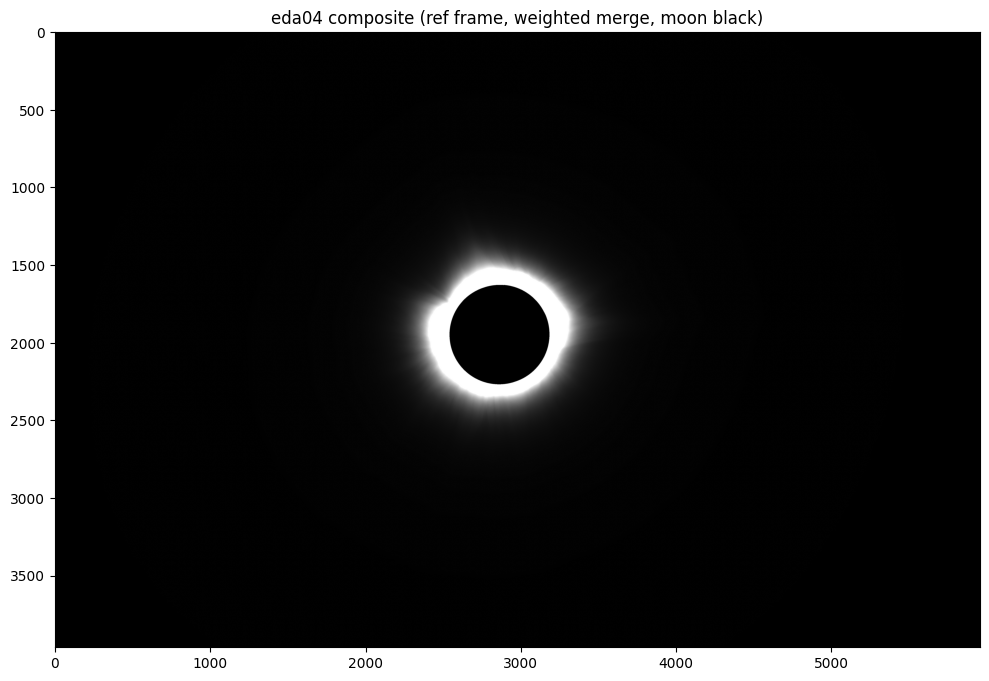

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(composite_crop, cmap="gray", vmin=0, vmax=np.percentile(composite_crop[composite_crop > 0], 99) if np.any(composite_crop > 0) else 1)
ax.set_title("eda04 composite (ref frame, weighted merge, moon black)")
plt.tight_layout()
plt.show()

In [9]:
# find_moon + refine_moon from eda00.py: exact moon (center, radius) from edge gradient, given initial (i0, j0)
import math
import random
import numpy as np
import torch
from scipy.cluster.hierarchy import linkage, fcluster

N_SECTORS = 360
N_TRIPLETS = 1024
N_CLUSTER = 256
REFINE_ITERATIONS = 3
MIN_TRIPLET_DEGREES = 30

def _indices_within_degrees(center: int, deg: int) -> set:
    return {(center + d) % N_SECTORS for d in range(-(deg - 1), deg)}

def sample_triplet_indices(n_pts: int, min_degrees: int = MIN_TRIPLET_DEGREES):
    available = set(range(n_pts))
    a = random.sample(list(available), 1)[0]
    available -= _indices_within_degrees(a, min_degrees) & available
    assert len(available) >= 2
    b = random.sample(list(available), 1)[0]
    available -= _indices_within_degrees(b, min_degrees) & available
    assert len(available) >= 1
    c = random.sample(list(available), 1)[0]
    return (a, b, c)

def refine_moon(img: torch.Tensor, center_i: float, center_j: float):
    assert img.ndim == 3 and img.shape[2] == 3
    H, W = img.shape[0], img.shape[1]
    dev = img.device
    img_size = float(max(H, W))
    gray = img.mean(dim=2)
    sobel_x = torch.tensor(
        [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32, device=dev
    ).view(1, 1, 3, 3)
    sobel_y = torch.tensor(
        [[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32, device=dev
    ).view(1, 1, 3, 3)
    g = gray.unsqueeze(0).unsqueeze(0)
    grad_x = torch.nn.functional.conv2d(g, sobel_x, padding=1).squeeze()
    grad_y = torch.nn.functional.conv2d(g, sobel_y, padding=1).squeeze()
    dy = torch.arange(H, device=dev, dtype=torch.float32).view(-1, 1) - center_i
    dx = torch.arange(W, device=dev, dtype=torch.float32).view(1, -1) - center_j
    norm = torch.sqrt(dx * dx + dy * dy).clamp(min=1e-6)
    u_x, u_y = dx / norm, dy / norm
    angle = torch.atan2(dy, dx)
    sector_id = (
        torch.floor((angle + math.pi) / (2 * math.pi) * N_SECTORS).long() % N_SECTORS
    )
    dot_product = grad_x * u_x + grad_y * u_y
    dot_product_flat = dot_product.reshape(-1)
    sector_flat = sector_id.reshape(-1)
    W_t = W
    points_list = []
    for s in range(N_SECTORS):
        mask = sector_flat == s
        if mask.any():
            masked = torch.where(
                mask, dot_product_flat, torch.tensor(-1e9, device=dev, dtype=torch.float32)
            )
            idx = masked.argmax().item()
            i, j = idx // W_t, idx % W_t
            points_list.append((i, j))
    n_pts = len(points_list)
    if n_pts < 3:
        return (center_i, center_j, 0.0)

    def circumcenter(i1, j1, i2, j2, i3, j3):
        x1, y1 = float(j1), float(i1)
        x2, y2 = float(j2), float(i2)
        x3, y3 = float(j3), float(i3)
        D = 2.0 * (x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2))
        if abs(D) < 1e-10:
            return None
        ox = (
            (x1 * x1 + y1 * y1) * (y2 - y3)
            + (x2 * x2 + y2 * y2) * (y3 - y1)
            + (x3 * x3 + y3 * y3) * (y1 - y2)
        ) / D
        oy = (
            (x1 * x1 + y1 * y1) * (x3 - x2)
            + (x2 * x2 + y2 * y2) * (x1 - x3)
            + (x3 * x3 + y3 * y3) * (x2 - x1)
        ) / D
        oi, oj = oy, ox
        d1 = math.hypot(i1 - oi, j1 - oj)
        d2 = math.hypot(i2 - oi, j2 - oj)
        d3 = math.hypot(i3 - oi, j3 - oj)
        if d1 > img_size or d2 > img_size or d3 > img_size:
            return None
        radius = (d1 + d2 + d3) / 3.0
        return (oi, oj, radius)

    circumcenters, radii = [], []
    while len(circumcenters) < N_TRIPLETS:
        a, b, c = sample_triplet_indices(n_pts)
        i1, j1 = points_list[a]
        i2, j2 = points_list[b]
        i3, j3 = points_list[c]
        cc_result = circumcenter(i1, j1, i2, j2, i3, j3)
        if cc_result is not None:
            oi, oj, radius = cc_result
            circumcenters.append((oi, oj))
            radii.append(radius)
    pts = np.array(circumcenters, dtype=np.float64)
    Z = linkage(pts, method="complete")
    t_lo, t_hi = 0.0, float(Z[-1, 2])
    for _ in range(60):
        t = (t_lo + t_hi) / 2
        labels = fcluster(Z, t, criterion="distance")
        sizes = np.bincount(labels)
        max_size = int(sizes.max())
        if max_size >= N_CLUSTER:
            t_hi = t
        else:
            t_lo = t
    labels = fcluster(Z, t_hi, criterion="distance")
    sizes = np.bincount(labels)
    which = int(np.argmax(sizes))
    cluster_mask = labels == which
    cluster_pts = pts[cluster_mask]
    cluster_radii = np.array(radii)[cluster_mask]
    ci = float(cluster_pts[:, 0].mean())
    cj = float(cluster_pts[:, 1].mean())
    radius = float(cluster_radii.mean())
    return (ci, cj, radius)

def find_moon(img: torch.Tensor, i0: float, j0: float):
    assert img.ndim == 3 and img.shape[2] == 3
    center_i, center_j = i0, j0
    radius = 0.0
    for _ in range(REFINE_ITERATIONS):
        center_i, center_j, radius = refine_moon(img, center_i, center_j)
    return (center_i, center_j, radius)

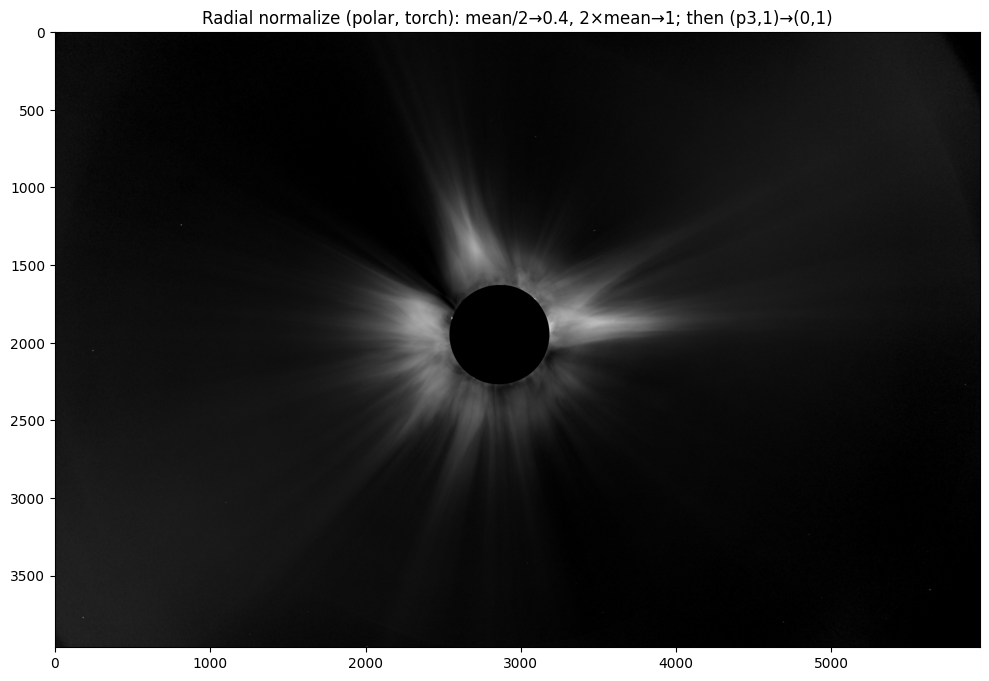

Saved /home/slavik/tmp/eda04_radial_normalize.png


In [10]:
# Same radial normalize (mean/2->0.4, mean->0.4, 2*mean->1; then p3->0, 1->1) via polar view, torch GPU float64
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import torchvision
from scipy.ndimage import gaussian_filter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64

# Center in crop and r_max to farthest corner so polar covers full crop
def dist_to_corners(ci, cj, H, W):
    corners = [(0, 0), (H - 1, 0), (0, W - 1), (H - 1, W - 1)]
    return max(math.sqrt((i - ci) ** 2 + (j - cj) ** 2) for i, j in corners)

def image_to_polar_f64(img, center, radius_min, radius_max, n_r, n_theta, device, dtype):
    """img: (H,W) tensor; returns (polar_image, mask) shape (n_r, n_theta). 1 polar px <= 0.5 cartesian."""
    H, W = img.shape
    ci, cj = center[0], center[1]
    y = torch.arange(n_r, device=device, dtype=dtype).view(-1, 1)
    x = torch.arange(n_theta, device=device, dtype=dtype).view(1, -1)
    # r from radius_max (y=0) down to radius_min (y=n_r-1)
    r = radius_max - y * (radius_max - radius_min) / max(n_r - 1, 1)
    if n_theta > 1:
        theta = 2 * math.pi * x / (n_theta - 1)
    else:
        theta = torch.zeros_like(x, device=device, dtype=dtype)
    i_src = ci + r * torch.sin(theta)
    j_src = cj + r * torch.cos(theta)
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    polar = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    ).squeeze(0).squeeze(0)
    mask = (i_src >= 0) & (i_src < H) & (j_src >= 0) & (j_src < W)
    return polar, mask.squeeze(-1) if mask.dim() > 2 else mask

def polar_to_cartesian_f64(polar, center, radius_min, radius_max, H, W, device, dtype):
    """polar (n_r, n_theta) -> cartesian (H, W). Bilinear; zeros outside [radius_min, radius_max]."""
    n_r, n_theta = polar.shape
    ci, cj = center[0], center[1]
    i = torch.arange(H, device=device, dtype=dtype).view(-1, 1)
    j = torch.arange(W, device=device, dtype=dtype).view(1, -1)
    r = torch.sqrt((i - ci) ** 2 + (j - cj) ** 2)
    theta = torch.atan2(i - ci, j - cj)
    theta = torch.where(theta < 0, theta + 2 * math.pi, theta)
    y_polar = (radius_max - r) * (n_r - 1) / max(radius_max - radius_min, 1e-9)
    x_polar = theta / (2 * math.pi) * (n_theta - 1) if n_theta > 1 else torch.zeros_like(theta)
    x_norm = 2.0 * x_polar / (n_theta - 1) - 1.0 if n_theta > 1 else torch.zeros_like(x_polar)
    y_norm = 2.0 * y_polar / (n_r - 1) - 1.0 if n_r > 1 else torch.zeros_like(y_polar)
    grid = torch.stack([x_norm, y_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        polar.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    ).squeeze(0).squeeze(0)
    valid = (r >= radius_min) & (r <= radius_max)
    return torch.where(valid, out, torch.zeros_like(out))

def vertical_gaussian_blur(x: torch.Tensor, kernel_size: int = 7, sigma: float = 1.0) -> torch.Tensor:
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be odd")

    ax = torch.arange(kernel_size) - kernel_size // 2
    kernel = torch.exp(-(ax**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    kernel = kernel.view(1, 1, -1, 1)  # vertical blur
    x = x.unsqueeze(0).unsqueeze(0)    # [1, 1, H, W]
    y = F.conv2d(x, kernel.to(x.dtype).to(x.device), padding=(kernel_size // 2, 0))
    return y.squeeze(0).squeeze(0)

# Input: composite_crop, moon center, moon_r (from previous cells). Refine with find_moon from eda00.
img_rgb = torch.from_numpy(composite_crop).to(device=device, dtype=torch.float32).unsqueeze(-1).expand(-1, -1, 3)
mi_crop, mj_crop, moon_r = find_moon(img_rgb, float(mi_crop), float(mj_crop))
ii = np.arange(H_crop, dtype=np.float64).reshape(-1, 1)
jj = np.arange(W_crop, dtype=np.float64).reshape(1, -1)
dist_sq = (ii - mi_crop) ** 2 + (jj - mj_crop) ** 2
moon_mask = dist_sq <= (moon_r ** 2)

img = torch.from_numpy(composite_crop).to(device=device, dtype=dtype)
center = (float(mi_crop), float(mj_crop))
radius_min = 0.0
radius_max = dist_to_corners(mi_crop, mj_crop, H_crop, W_crop)
# Polar resolution: 1 polar px <= 0.5 cartesian px
n_r = max(int(math.ceil(2 * (radius_max - radius_min))) + 1, 2)
n_theta = max(int(math.ceil(4 * math.pi * radius_max)) + 1, 2)

polar_img, valid = image_to_polar_f64(img, center, radius_min, radius_max, n_r, n_theta, device, dtype)
# valid = True where polar sample is inside crop (same as polar view of ones_like)

# Sliding-window mean: fraction of row centered on each pixel (periodic), fully vectorized via cumsum
display_ts = list()
mean_at_list = list()
row_fractions = [0.15, 1.0]
for row_fraction in row_fractions:
    n_cols_use = max(1, int(n_theta * row_fraction))
    half_window = n_cols_use // 2
    # Extend polars horizontally (periodicity) then cumsum along theta
    polar_ext = torch.cat([polar_img, polar_img, polar_img], dim=1)  # (n_r, 3*n_theta)
    valid_ext = torch.cat([valid, valid, valid], dim=1)
    row_val_ext = (polar_ext * valid_ext).to(dtype)
    row_cnt_ext = valid_ext.to(dtype)
    cs_val = torch.cumsum(torch.cat([torch.zeros(n_r, 1, device=device, dtype=dtype), row_val_ext], dim=1), dim=1)  # (n_r, 3*n_theta+1)
    cs_cnt = torch.cumsum(torch.cat([torch.zeros(n_r, 1, device=device, dtype=dtype), row_cnt_ext], dim=1), dim=1)
    start = (n_theta - half_window + torch.arange(n_theta, device=device)).long()  # (n_theta,)
    sum_v = cs_val[:, start + n_cols_use] - cs_val[:, start]  # (n_r, n_theta)
    sum_n = (cs_cnt[:, start + n_cols_use] - cs_cnt[:, start]).clamp(min=1e-20)
    mean_polar_2d = sum_v / sum_n
    # for each column, fill items located under argmax location with the max values
    assert torch.all(torch.isfinite(mean_polar_2d))
    argmax = mean_polar_2d.argmax(dim=0)
    max_val = mean_polar_2d.max(dim=0).values  # shape: [num_columns]
    mask = torch.arange(mean_polar_2d.size(0), device=mean_polar_2d.device).unsqueeze(1) > argmax # create a mask for elements below the max (row index > argmax)
    mean_polar_2d[mask] = max_val.unsqueeze(0).expand_as(mean_polar_2d)[mask]
    
    mean_at = polar_to_cartesian_f64(mean_polar_2d, center, radius_min, radius_max, H_crop, W_crop, device, dtype)
    mean_at_list.append(mean_at.cpu().numpy())
    # Piecewise: mean/2->0, mean->0.4, 2*mean->1
    valid_mask = torch.isfinite(mean_at) & (mean_at > 0)
    display_t = torch.zeros_like(img, device=device, dtype=dtype)
    v = img[valid_mask]
    m = mean_at[valid_mask]
    mask1 = (v > m / 2) & (v <= m)
    mask2 = (v > m) & (v <= 2 * m)
    mask3 = v > 2 * m
    display_t[valid_mask] = torch.where(mask1, 0.4 * (v - m / 2) / (m / 2).clamp(min=1e-9), torch.zeros_like(v))
    display_t[valid_mask] = torch.where(mask2, 0.4 + 0.6 * (v - m) / m.clamp(min=1e-9), display_t[valid_mask])
    display_t[valid_mask] = torch.where(mask3, torch.ones_like(v), display_t[valid_mask])
    display_ts.append(display_t)
display_t = torch.stack(display_ts).mean(dim=0)

# p3 in polar
polar_display, _ = image_to_polar_f64(display_t, center, radius_min, radius_max, n_r, n_theta, device, dtype)
blur = torchvision.transforms.GaussianBlur(kernel_size=13, sigma=5)
valid = (blur(valid.float().unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0) > 0.9)
polar_display[valid == False] = 1.0
q = torch.linspace(start=0.03, end=0.0001, steps=polar_display.shape[0], device=polar_display.device, dtype=polar_display.dtype)
p3_row = polar_display.quantile(q=q, dim=1)
p3_row = p3_row.diag()
p3_smooth = vertical_gaussian_blur(p3_row.unsqueeze(1), kernel_size=133, sigma=33).squeeze(1)
p3_polar_2d = p3_smooth.unsqueeze(1).expand(n_r, n_theta)
p3_at = polar_to_cartesian_f64(p3_polar_2d, center, radius_min, radius_max, H_crop, W_crop, device, dtype)
p3_at = torch.nan_to_num(p3_at, nan=0.0)

# (p3, 1) -> (0, 1)
span = (1.0 - p3_at).clamp(min=1e-9)
display_t = ((display_t - p3_at) / span).clamp(0.0, 1.0)
#display_t[torch.from_numpy(moon_mask).to(device=device)] = 0.0

display_np = display_t.cpu().numpy()
display = display_np  # for downstream cells (sharpening, etc.)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(display, cmap="gray", vmin=0, vmax=1)
ax.set_title("Radial normalize (polar, torch): mean/2→0.4, 2×mean→1; then (p3,1)→(0,1)")
plt.tight_layout()
plt.show()
Image.fromarray((display * 255).clip(0, 255).astype(np.uint8)).save(Path(PKL_DIR) / "eda04_radial_normalize.png")
print(f"Saved {Path(PKL_DIR) / 'eda04_radial_normalize.png'}")

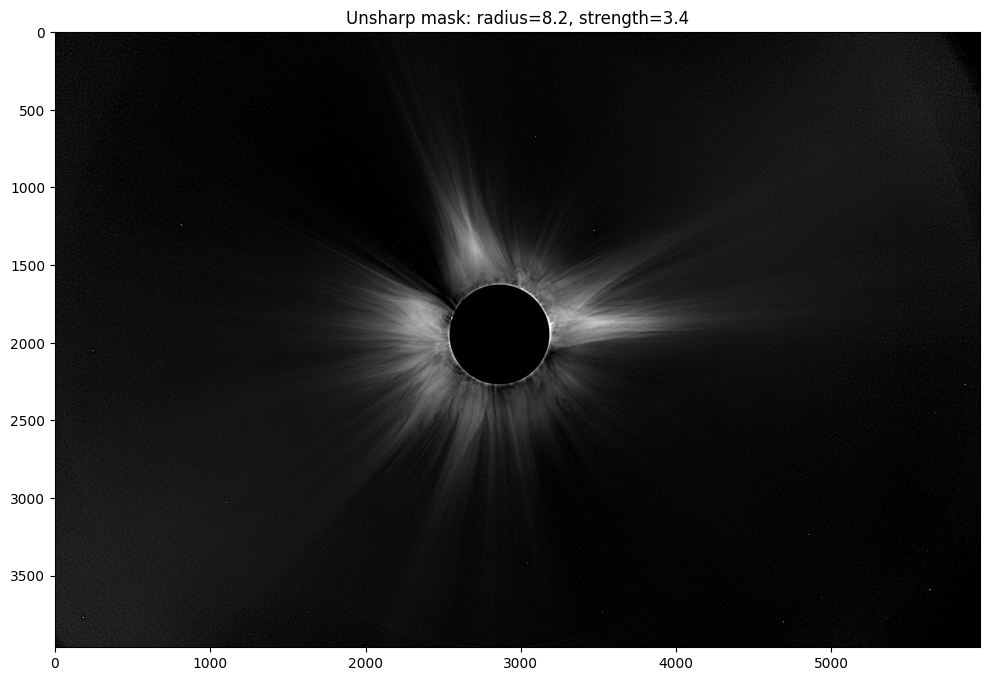

In [11]:
# Unsharp mask: sharpen display with radius (Gaussian sigma) 4.2, strength 3.4
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from PIL import Image

# fill moon disk with reasonable values, otherwise sharpen would make white ring around it
###polar_display, _ = image_to_polar_f64(display_t, center, radius_min, radius_max, n_r, n_theta, device, dtype)
###argmax = polar_display.argmax(dim=0)
###max_val = polar_display.max(dim=0).values  # shape: [num_columns]
###mask = torch.arange(polar_display.size(0), device=polar_display.device).unsqueeze(1) > argmax # create a mask for elements below the max (row index > argmax)
###polar_display[mask] = max_val.unsqueeze(0).expand_as(polar_display)[mask]
###display2 = polar_to_cartesian_f64(polar_display, center, radius_min, radius_max, H_crop, W_crop, device, dtype)
###display = display2.detach().cpu().numpy()

radius = 8.2   # Gaussian sigma for blur (pixels)
strength = 3.4
blurred = gaussian_filter(display, sigma=radius, mode="nearest")
sharpened = display + strength * (display - blurred)
sharpened = np.clip(sharpened, 0.0, 1.0)
sharpened[moon_mask] = 0.0

Image.fromarray((sharpened * 255).clip(0, 255).astype(np.uint8)).save("/home/slavik/tmp/eda04_radial_normalize_sharpen.png")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(sharpened, cmap="gray", vmin=0, vmax=1)
ax.set_title("Unsharp mask: radius=8.2, strength=3.4")
plt.tight_layout()
plt.show()

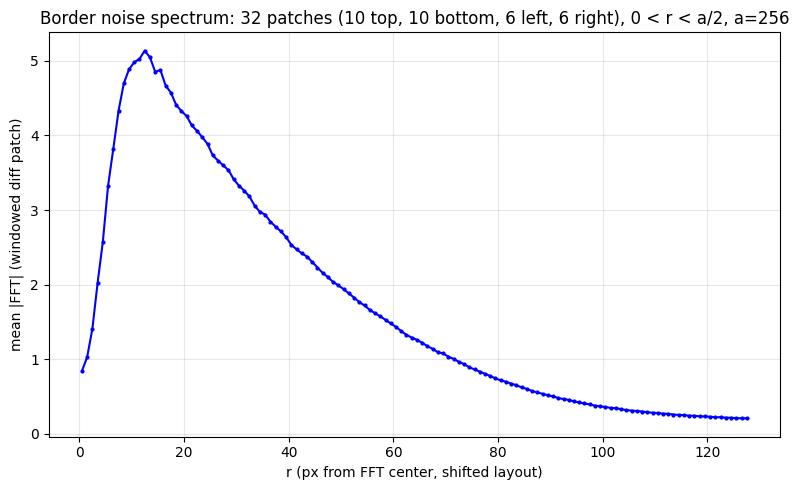

In [12]:
# collect noise stats: border patches on diff, windowed FFT, mean radial |FFT| vs r (0 < r < a/2)
import numpy as np
import torch
import matplotlib.pyplot as plt

a = 256

def patch_window_flat_circle(a, dtype=np.float64):
    ci = (a - 1) / 2.0
    cj = (a - 1) / 2.0
    ii = np.arange(a, dtype=dtype).reshape(-1, 1)
    jj = np.arange(a, dtype=dtype).reshape(1, -1)
    r = np.hypot(ii - ci, jj - cj)
    R_flat = 0.667 * a / 2.0
    R_max = float(np.hypot(ci, cj))
    denom = max(R_max - R_flat, 1e-12)
    t = np.clip((r - R_flat) / denom, 0.0, 1.0)
    w = np.where(r <= R_flat, 1.0, 0.5 * (1.0 + np.cos(np.pi * t)))
    w = np.where(r >= R_max, 0.0, w)
    return w.astype(np.float32, copy=False)

diff = (display.astype(np.float64) - blurred.astype(np.float64)).astype(np.float32)
H, W = diff.shape
assert H >= a and W >= a, (H, W, a)

# Top / bottom: 10 patches each, top-left j in middle 50% of [0, W-a]; bottom row i = H-a
j_margin = max(0, (W - a) // 4)
j_lo, j_hi = j_margin, (W - a) - j_margin
if j_hi < j_lo:
    j_lo, j_hi = 0, W - a
j_top = np.linspace(j_lo, j_hi, 10, dtype=int)
i_bot = H - a

# Left / right: 6 patches each, top-left i in middle 50% of [0, H-a]; right col j = W-a
i_margin = max(0, (H - a) // 4)
i_lo, i_hi = i_margin, (H - a) - i_margin
if i_hi < i_lo:
    i_lo, i_hi = 0, H - a
i_left = np.linspace(i_lo, i_hi, 6, dtype=int)
j_right = W - a

ij_list = [(0, int(j)) for j in j_top]
ij_list += [(i_bot, int(j)) for j in j_top]
ij_list += [(int(i), 0) for i in i_left]
ij_list += [(int(i), j_right) for i in i_left]

win_np = patch_window_flat_circle(a)
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
win = torch.from_numpy(win_np).to(dev)

ci = (a - 1) / 2.0
cj = (a - 1) / 2.0
ii = np.arange(a, dtype=np.float64).reshape(-1, 1)
jj = np.arange(a, dtype=np.float64).reshape(1, -1)
rr = np.hypot(ii - ci, jj - cj)
ring = (rr > 1e-9) & (rr < 0.5 * a - 1e-9)
n_bins = min(128, max(8, a // 2))
r_max_ring = 0.5 * a
dr = r_max_ring / n_bins
bin_idx = np.floor(rr / dr).astype(np.int32)
bin_idx = np.clip(bin_idx, 0, n_bins - 1)
use = ring
b_flat = bin_idx[use]

sum_amp = np.zeros(n_bins, dtype=np.float64)
cnt = np.zeros(n_bins, dtype=np.int64)
for i0, j0 in ij_list:
    assert 0 <= i0 and 0 <= j0 and i0 + a <= H and j0 + a <= W, (i0, j0, H, W, a)
    patch = torch.from_numpy(diff[i0 : i0 + a, j0 : j0 + a]).to(device=dev, dtype=torch.float32)
    p_w = patch * win
    F_fft = torch.fft.fft2(p_w)
    Fs = torch.fft.fftshift(F_fft)
    amp = torch.abs(Fs).detach().cpu().numpy()
    a_flat = amp[use]
    np.add.at(sum_amp, b_flat, a_flat)
    np.add.at(cnt, b_flat, 1)

r_centers = (np.arange(n_bins, dtype=np.float64) + 0.5) * dr
mean_amp = np.divide(sum_amp, np.maximum(cnt, 1), out=np.zeros_like(sum_amp), where=cnt > 0)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(r_centers[cnt > 0], mean_amp[cnt > 0], "b.-", markersize=4)
ax.set_xlabel("r (px from FFT center, shifted layout)")
ax.set_ylabel("mean |FFT| (windowed diff patch)")
ax.set_title(
    f"Border noise spectrum: {len(ij_list)} patches (10 top, 10 bottom, 6 left, 6 right), "
    f"0 < r < a/2, a={a}"
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

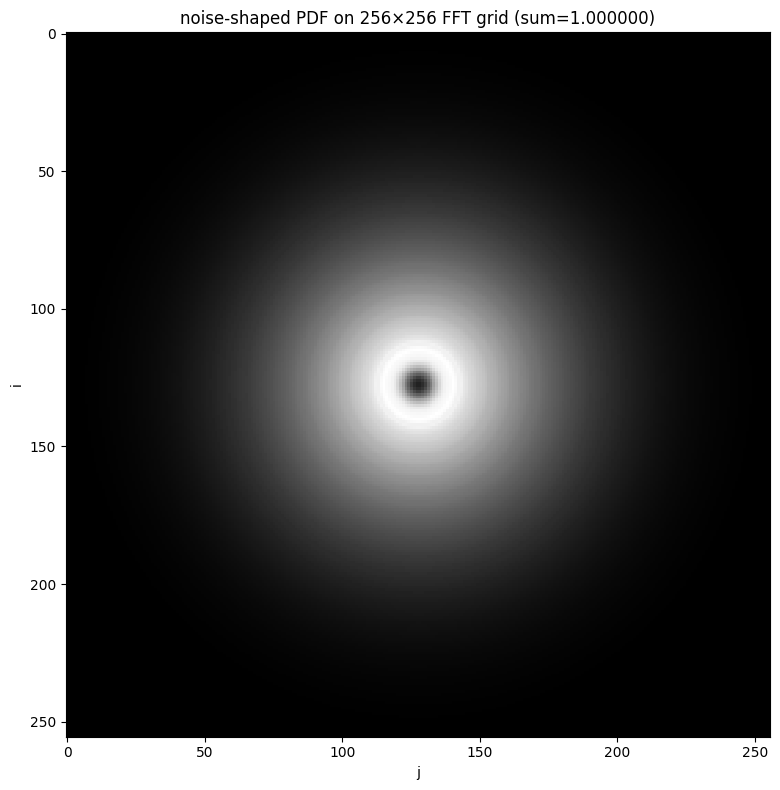

In [13]:
# noise pdf: a×a map from border radial mean |FFT| (prev cell); r>a/2 → value at r=a/2; normalize to sum 1
import numpy as np
import matplotlib.pyplot as plt

valid = cnt > 0
r_v = r_centers[valid].astype(np.float64)
amp_v = mean_amp[valid].astype(np.float64)
order = np.argsort(r_v)
r_v, amp_v = r_v[order], amp_v[order]

ci = (a - 1) / 2.0
cj = (a - 1) / 2.0
ii = np.arange(a, dtype=np.float64).reshape(-1, 1)
jj = np.arange(a, dtype=np.float64).reshape(1, -1)
rr = np.hypot(ii - ci, jj - cj)
rr_eff = np.minimum(rr, 0.5 * a)
vals = np.interp(rr_eff, r_v, amp_v, left=amp_v[0], right=amp_v[-1])

pdf = vals / vals.sum()

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(pdf, cmap="gray", interpolation="nearest")
ax.set_title(f"noise-shaped PDF on {a}×{a} FFT grid (sum={pdf.sum():.6f})")
ax.set_xlabel("j")
ax.set_ylabel("i")
plt.tight_layout()
plt.show()

In [14]:
# Radial noise template (border mean_amp vs r_centers): scale c in annulus a/4 < r <= a/2,
# then m = max(0, |F| - c*n(r)) / |F| for r > 5 px; else m = 1. n(r) via np.interp, no cap at a/2.
import numpy as np
import torch

def make_fft_mask3_for_tile(Fs):
    """Multiplicative mask m per FFT bin: m*|F| = max(0, |F| - c*n(r)) where r > 5 from center; else m=1.

    c = min(100, mean(|F|)/mean(n(r))) on a/4 < r <= a/2; n(r) interpolated from border radial curve.
    """
    if isinstance(Fs, torch.Tensor):
        shp = tuple(Fs.shape)
        dev = Fs.device
    else:
        shp = np.asarray(Fs).shape
        dev = None
    if len(shp) != 2 or shp[0] != shp[1]:
        raise ValueError(f"Fs must be square a×a, got {shp}")
    aa = shp[0]
    if aa != a:
        raise ValueError(f"Fs grid {shp} must match a={a}")

    valid = cnt > 0
    r_v = r_centers[valid].astype(np.float64)
    amp_v = mean_amp[valid].astype(np.float64)
    order = np.argsort(r_v)
    r_v, amp_v = r_v[order], amp_v[order]
    if r_v.size == 0:
        raise ValueError("noise radial curve has no valid bins (cnt > 0)")

    ci = (aa - 1) / 2.0
    cj = (aa - 1) / 2.0
    ii = np.arange(aa, dtype=np.float64).reshape(-1, 1)
    jj = np.arange(aa, dtype=np.float64).reshape(1, -1)
    rr = np.hypot(ii - ci, jj - cj)

    if isinstance(Fs, torch.Tensor):
        amp = torch.abs(Fs).detach().float().cpu().numpy().astype(np.float64)
    else:
        amp = np.abs(np.asarray(Fs)).astype(np.float64)

    annulus = (rr > 0.25 * aa) & (rr <= 0.5 * aa)
    if not np.any(annulus):
        raise ValueError("annulus a/4 < r <= a/2 is empty for this grid size")
    n_ann = np.interp(rr[annulus], r_v, amp_v, left=amp_v[0], right=amp_v[-1])
    ref_mean = float(np.mean(n_ann))
    obs_mean = float(np.mean(amp[annulus]))
    if ref_mean > 0:
        c = min(100.0, obs_mean / ref_mean)
    else:
        c = 0.0

    n_r = np.interp(rr, r_v, amp_v, left=amp_v[0], right=amp_v[-1])
    corrected = np.maximum(0.0, amp - 1.5 * c * n_r)
    apply_m = rr > 5.0
    m = np.ones_like(amp, dtype=np.float64)
    sub = amp[apply_m]
    m[apply_m] = np.where(sub > 0, corrected[apply_m] / sub, 0.0)

    if isinstance(Fs, torch.Tensor):
        return torch.as_tensor(m, dtype=torch.float32, device=dev)
    return m.astype(np.float32)

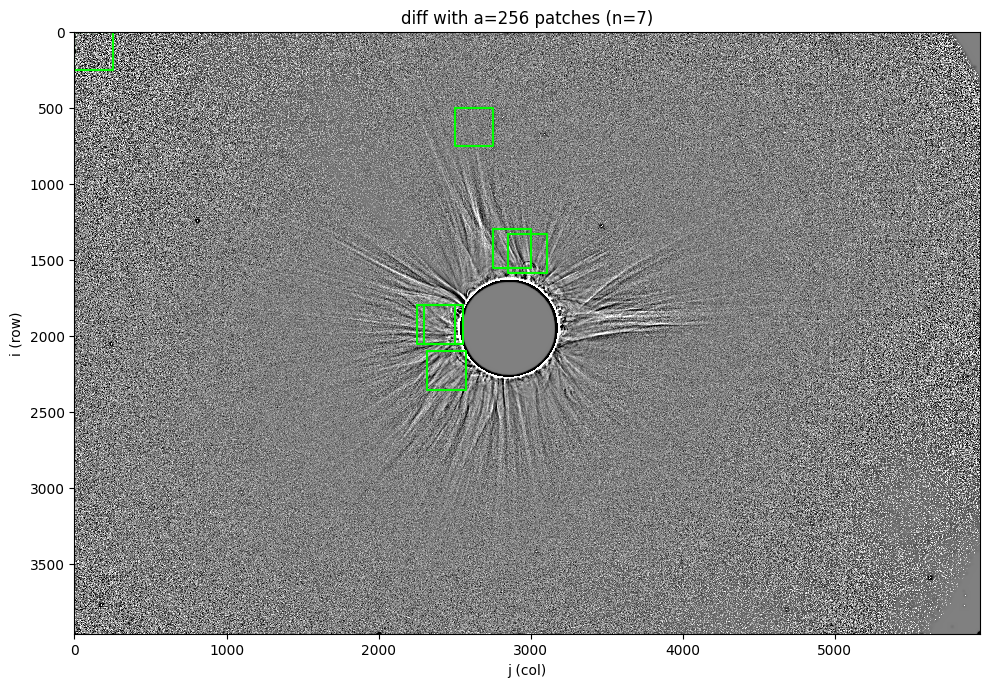

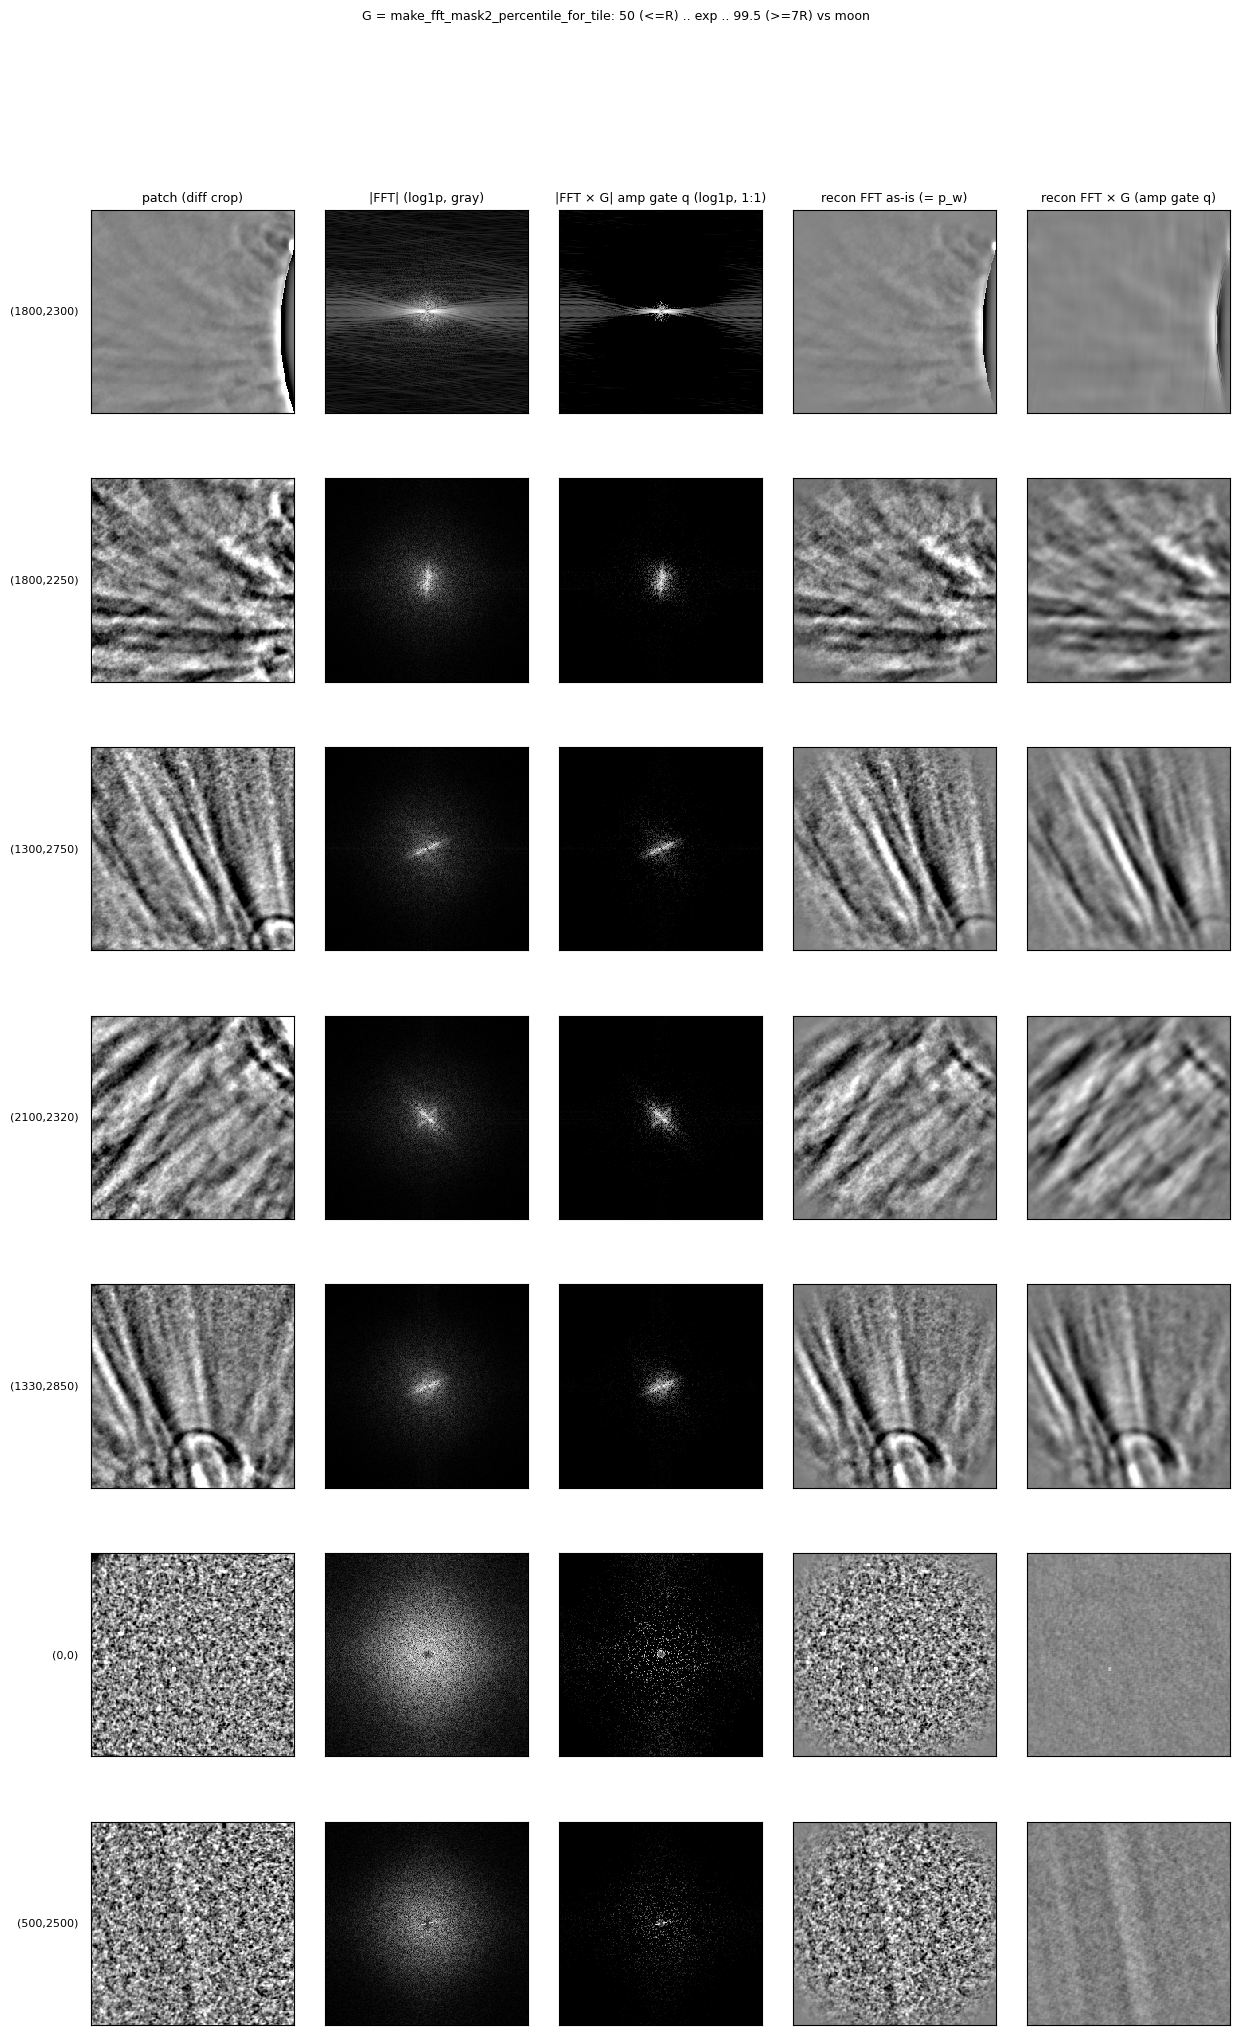

patch (1800,2300): max |recon_as_is - p_w| = 8.941e-08 (should be ~0)
patch (1800,2250): max |recon_as_is - p_w| = 9.313e-09 (should be ~0)
patch (1300,2750): max |recon_as_is - p_w| = 7.451e-09 (should be ~0)
patch (2100,2320): max |recon_as_is - p_w| = 9.313e-09 (should be ~0)
patch (1330,2850): max |recon_as_is - p_w| = 9.313e-09 (should be ~0)
patch (0,0): max |recon_as_is - p_w| = 4.470e-08 (should be ~0)
patch (500,2500): max |recon_as_is - p_w| = 5.588e-09 (should be ~0)


In [15]:
# FFT patch playground: same windowing / G as the whole-image sliding FFT cell below
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

# Top-left corners (row i, col j) for each a×a patch — tuple of (i, j) pairs
IJ_PAIRS = (
    (1800, 2300),
    (1800, 2250),
    (1300, 2750),
    (2100, 2320),
    (1330, 2850),
    (0, 0),
    (500, 2500),
)

def patch_window_flat_circle(a, dtype=np.float64):
    ci = (a - 1) / 2.0
    cj = (a - 1) / 2.0
    ii = np.arange(a, dtype=dtype).reshape(-1, 1)
    jj = np.arange(a, dtype=dtype).reshape(1, -1)
    r = np.hypot(ii - ci, jj - cj)
    R_flat = 0.667 * a / 2.0
    R_max = float(np.hypot(ci, cj))
    denom = max(R_max - R_flat, 1e-12)
    t = np.clip((r - R_flat) / denom, 0.0, 1.0)
    w = np.where(r <= R_flat, 1.0, 0.5 * (1.0 + np.cos(np.pi * t)))
    w = np.where(r >= R_max, 0.0, w)
    return w.astype(np.float32, copy=False)

def make_fft_mask2_percentile_for_tile(
    Fs, ci, cj, moon_i, moon_j, moon_r, vals, epsilon=1e-12, dens_eps_scale=0.1, p_near=90.0, p_far=99.8, exp_k=2.0
):
    """Amplitude gate q from shifted FFT Fs. Moon sets percentile p (p_near..p_far).
    vals: expected |FFT| per bin (global radial template, same layout as Fs). eps_d = dens_eps_scale * max(vals).
    R = |F|/(vals+eps_d); t_R = quantile(R,p/100); th = t_R*(vals+eps_d); q = clip(|F|-th,0)/(|F|+epsilon)."""
    R = max(float(moon_r), 1e-12)
    d = math.hypot(float(ci) - float(moon_i), float(cj) - float(moon_j))
    rho_moon = d / R
    if rho_moon <= 1.0:
        percentile = p_near
    elif rho_moon >= 7.0:
        percentile = p_far
    else:
        t = (7.0 - rho_moon) / 6.0
        v0 = 100.0 - p_far
        v1 = 100.0 - p_near
        v = v0 * (v1 / v0) ** t
        percentile = 100.0 - v
    aa = Fs.shape[0]
    assert Fs.shape == (aa, aa), Fs.shape
    dtype = Fs.real.dtype
    rho = torch.as_tensor(vals, device=Fs.device, dtype=dtype)
    assert rho.shape == Fs.shape, (rho.shape, Fs.shape)
    amplitude = torch.abs(Fs)
    eps_d = dens_eps_scale * rho.max()
    denom = rho + eps_d
    ratio = amplitude / denom.clamp(min=1e-12)
    t_R = torch.quantile(ratio.reshape(-1), percentile / 100.0)
    th = t_R * denom
    newampl = (amplitude - th).clamp(min=0)
    q = newampl / (amplitude + epsilon)
    return q.to(dtype=dtype)

H_d, W_d = display.shape
for i, j in IJ_PAIRS:
    assert 0 <= i and 0 <= j and i + a <= H_d and j + a <= W_d, (i, j, a, H_d, W_d)

diff_np = (display.astype(np.float64) - blurred.astype(np.float64)).astype(np.float32)
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

win_np = patch_window_flat_circle(a)
win = torch.from_numpy(win_np).to(dev)

# Global radial template: expected |FFT| on a×a (same cell order as fftshift(Fs))
valid = cnt > 0
r_v = r_centers[valid].astype(np.float64)
amp_v = mean_amp[valid].astype(np.float64)
order = np.argsort(r_v)
r_v, amp_v = r_v[order], amp_v[order]
ci = (a - 1) / 2.0
cj = (a - 1) / 2.0
ii = np.arange(a, dtype=np.float64).reshape(-1, 1)
jj = np.arange(a, dtype=np.float64).reshape(1, -1)
rr = np.hypot(ii - ci, jj - cj)
rr_eff = np.minimum(rr, 0.5 * a)
vals = np.interp(rr_eff, r_v, amp_v, left=amp_v[0], right=amp_v[-1])

rows = []
for i, j in IJ_PAIRS:
    patch = torch.from_numpy(diff_np[i : i + a, j : j + a]).to(device=dev, dtype=torch.float32)
    p_w = patch * win
    F_fft = torch.fft.fft2(p_w)
    Fs = torch.fft.fftshift(F_fft)
    amp = torch.abs(Fs)
    recon_as_is = torch.fft.ifft2(torch.fft.ifftshift(Fs)).real
    tc_i = i + 0.5 * (a - 1)
    tc_j = j + 0.5 * (a - 1)
    G = make_fft_mask2_percentile_for_tile(Fs, tc_i, tc_j, mi_crop, mj_crop, moon_r, vals)
    G = make_fft_mask3_for_tile(Fs)
    recon_smoothed = torch.fft.ifft2(torch.fft.ifftshift(Fs * G)).real
    amp_np = amp.detach().cpu().numpy()
    amp_log = np.log1p(amp_np)
    amp_log = amp_log / (amp_log.max() + 1e-9)
    # |Fs × G| with G = make_fft_mask2_percentile_for_tile (percentile from tile center vs moon)
    amp_g_np = torch.abs(Fs * G).detach().cpu().numpy()
    amp_g_log = np.log1p(amp_g_np)
    amp_g_log = amp_g_log / (amp_g_log.max() + 1e-9)
    p0 = patch.detach().cpu().numpy()
    p4 = recon_as_is.detach().cpu().numpy()
    p5 = recon_smoothed.detach().cpu().numpy()
    pr = 1, 99
    lo, hi = np.percentile(p0, pr)
    lo = min(lo, -1e-6)
    hi = max(hi, 1e-6)
    err_id = (recon_as_is - p_w).abs().max().item()
    rows.append((i, j, p0, amp_log, amp_g_log, p4, p5, lo, hi, err_id))

# --- Fig 1 (once): full diff with all a×a squares outlined ---
vlim = float(np.percentile(np.abs(diff_np), 99.0))
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 10))
ax1.imshow(diff_np, cmap="gray", vmin=-vlim, vmax=vlim, interpolation="nearest")
for i, j in IJ_PAIRS:
    ax1.plot(
        [j, j + a - 1, j + a - 1, j, j],
        [i, i, i + a - 1, i + a - 1, i],
        color="lime",
        linewidth=1.5,
    )
ax1.set_title(f"diff with a={a} patches (n={len(IJ_PAIRS)})")
ax1.set_xlabel("j (col)")
ax1.set_ylabel("i (row)")
plt.tight_layout()
plt.show()

# --- Fig 2: one row of five 1:1 panels per (i,j); column titles only on top row ---
n = len(rows)
dpi = 100
w_in = 5 * a / dpi
h_row_in = a / dpi * 1.12
# Extra vertical inches for suptitle + row labels so rows are not pushed too low
fig_h = n * h_row_in + 0.75 + min(n, 8) * 0.04
fig2, axes = plt.subplots(n, 5, figsize=(w_in, fig_h), dpi=dpi, squeeze=False)
col_titles = [
    "patch (diff crop)",
    "|FFT| (log1p, gray)",
    "|FFT × G| amp gate q (log1p, 1:1)",
    "recon FFT as-is (= p_w)",
    "recon FFT × G (amp gate q)",
]
kinds = ["gray", "amp_log", "amp_log", "gray", "gray"]
for r, row in enumerate(rows):
    i, j, p0, amp_log, amp_g_log, p4, p5, lo, hi, err_id = row
    imgs = [p0, amp_log, amp_g_log, p4, p5]
    for c in range(5):
        ax = axes[r, c]
        im = imgs[c]
        kind = kinds[c]
        if kind == "amp_log":
            ax.imshow(im, cmap="gray", vmin=None, vmax=None, origin="upper", interpolation="nearest")
        else:
            ax.imshow(im, cmap="gray", vmin=lo, vmax=hi, origin="upper", interpolation="nearest")
        if r == 0:
            ax.set_title(col_titles[c], fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
        if c == 0:
            ax.text(
                -0.06,
                0.5,
                f"({i},{j})",
                transform=ax.transAxes,
                fontsize=8,
                va="center",
                ha="right",
            )
plt.subplots_adjust(left=0.09, right=0.98, bottom=0.04, top=0.91, wspace=0.15)
fig2.suptitle(
    "G = make_fft_mask2_percentile_for_tile: 50 (<=R) .. exp .. 99.5 (>=7R) vs moon",
    fontsize=9,
    y=1.0,
)
plt.show()

for i, j, _p0, _al, _agl, _p4, _p5, _lo, _hi, err_id in rows:
    print(f"patch ({i},{j}): max |recon_as_is - p_w| = {err_id:.3e} (should be ~0)")

FFT-smooth diff rows:  46%|████▌     | 214/464 [02:58<03:29,  1.19it/s]/tmp/ipykernel_356439/1125628841.py:58: RuntimeWarning: invalid value encountered in divide
  m[apply_m] = np.where(sub > 0, corrected[apply_m] / sub, 0.0)
FFT-smooth diff rows: 100%|██████████| 464/464 [06:23<00:00,  1.21it/s]


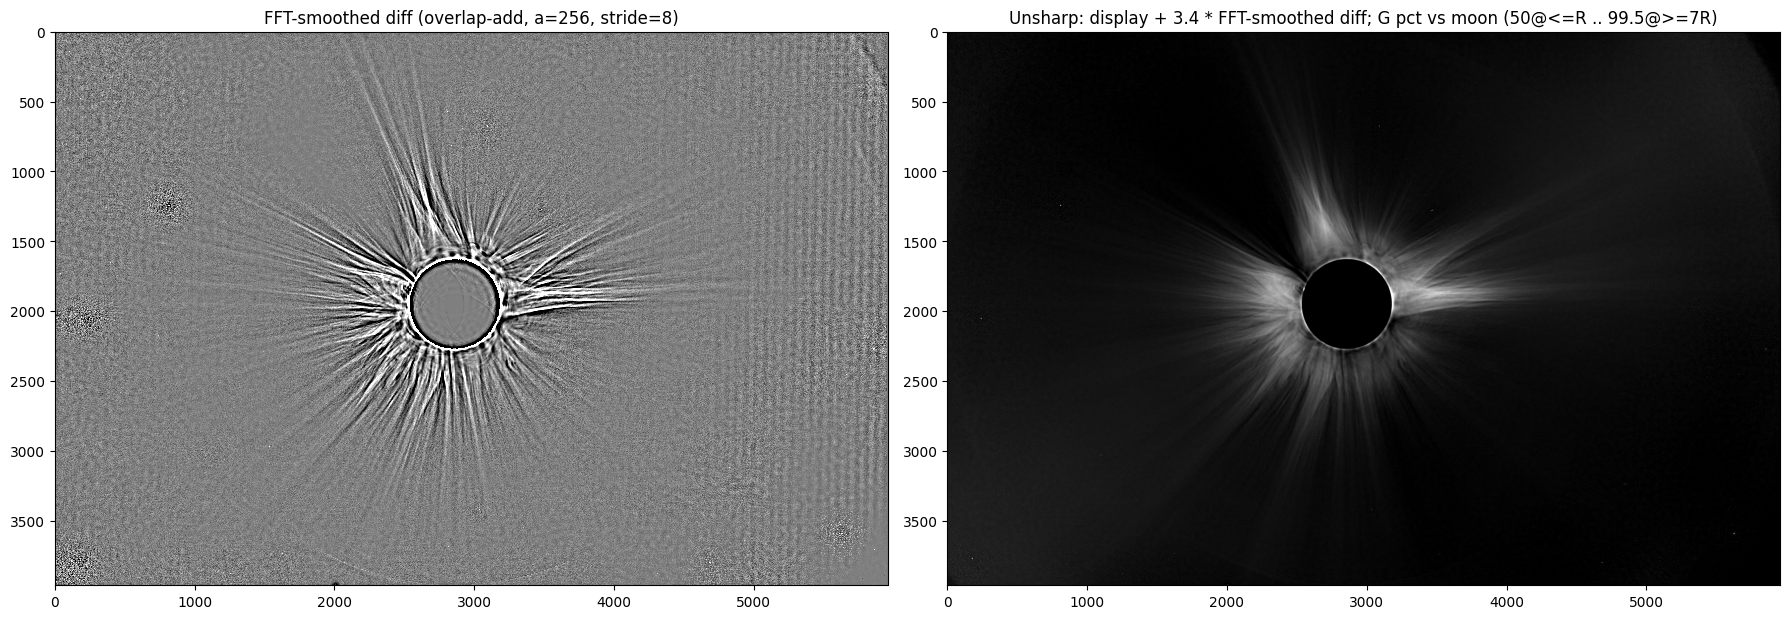

Saved /home/slavik/tmp/eda04_radial_normalize_sharpen_fft_smoothed_diff.png


In [16]:
# FFT-domain-smoothed residual (display − blurred): sliding a×a patches, overlap-add weighted by spatial window
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import tqdm
from pathlib import Path

# Amplitude gate G: make_fft_mask2_percentile_for_tile (same as FFT patch playground cell above).

def patch_window_flat_circle(a, dtype=np.float64):
    ci = (a - 1) / 2.0
    cj = (a - 1) / 2.0
    ii = np.arange(a, dtype=dtype).reshape(-1, 1)
    jj = np.arange(a, dtype=dtype).reshape(1, -1)
    r = np.hypot(ii - ci, jj - cj)
    R_flat = 0.667 * a / 2.0
    R_max = float(np.hypot(ci, cj))
    denom = max(R_max - R_flat, 1e-12)
    t = np.clip((r - R_flat) / denom, 0.0, 1.0)
    w = np.where(r <= R_flat, 1.0, 0.5 * (1.0 + np.cos(np.pi * t)))
    w = np.where(r >= R_max, 0.0, w)
    return w.astype(np.float32, copy=False)

a = 256
stride = 8
H_d, W_d = display.shape
assert H_d >= a and W_d >= a, (H_d, W_d, a)

diff_np = (display.astype(np.float64) - blurred.astype(np.float64)).astype(np.float32)
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
diff_t = torch.from_numpy(diff_np).to(device=dev, dtype=torch.float32)

win_np = patch_window_flat_circle(a)
win = torch.from_numpy(win_np).to(dev)

# Global radial template: expected |FFT| on a×a (same cell order as fftshift(Fs))
valid = cnt > 0
r_v = r_centers[valid].astype(np.float64)
amp_v = mean_amp[valid].astype(np.float64)
order = np.argsort(r_v)
r_v, amp_v = r_v[order], amp_v[order]
ci = (a - 1) / 2.0
cj = (a - 1) / 2.0
ii = np.arange(a, dtype=np.float64).reshape(-1, 1)
jj = np.arange(a, dtype=np.float64).reshape(1, -1)
rr = np.hypot(ii - ci, jj - cj)
rr_eff = np.minimum(rr, 0.5 * a)
vals = np.interp(rr_eff, r_v, amp_v, left=amp_v[0], right=amp_v[-1])

acc = torch.zeros(H_d, W_d, device=dev, dtype=torch.float32)
wsum = torch.zeros(H_d, W_d, device=dev, dtype=torch.float32)
row_starts = list(range(0, H_d - a + 1, stride))
col_starts = list(range(0, W_d - a + 1, stride))
for r0 in tqdm.tqdm(row_starts, desc="FFT-smooth diff rows"):
    for c0 in col_starts:
        patch = diff_t[r0 : r0 + a, c0 : c0 + a]
        p_w = patch * win
        F_fft = torch.fft.fft2(p_w)
        Fs = torch.fft.fftshift(F_fft)
        tc_i = r0 + 0.5 * (a - 1)
        tc_j = c0 + 0.5 * (a - 1)
        G = make_fft_mask2_percentile_for_tile(Fs, tc_i, tc_j, mi_crop, mj_crop, moon_r, vals)
        G = make_fft_mask3_for_tile(Fs)
        Fm = torch.fft.ifftshift(Fs * G)
        recon = torch.fft.ifft2(Fm).real
        acc[r0 : r0 + a, c0 : c0 + a] += recon * win
        wsum[r0 : r0 + a, c0 : c0 + a] += win

diff_smooth = (acc / wsum.clamp(min=1e-9)).cpu().numpy()
sharpened_fft_diff = display + 2 * strength * diff_smooth
sharpened_fft_diff = np.clip(sharpened_fft_diff, 0.0, 1.0)
sharpened_fft_diff[moon_mask] = 0.0

out_png = Path(PKL_DIR) / "eda04_radial_normalize_sharpen_fft_smoothed_diff.png"
Image.fromarray((sharpened_fft_diff * 255).clip(0, 255).astype(np.uint8)).save(out_png)
vlim_ds = float(np.percentile(np.abs(diff_smooth), 99.0))
vlim_ds = max(vlim_ds, 1e-9)
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
axes[0].imshow(diff_smooth, cmap="gray", vmin=-vlim_ds, vmax=vlim_ds, interpolation="nearest")
axes[0].set_title(f"FFT-smoothed diff (overlap-add, a={a}, stride={stride})")
axes[1].imshow(sharpened_fft_diff, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(
    f"Unsharp: display + {strength} * FFT-smoothed diff; G pct vs moon (50@<=R .. 99.5@>=7R)"
)
plt.tight_layout()
plt.show()
print(f"Saved {out_png}")

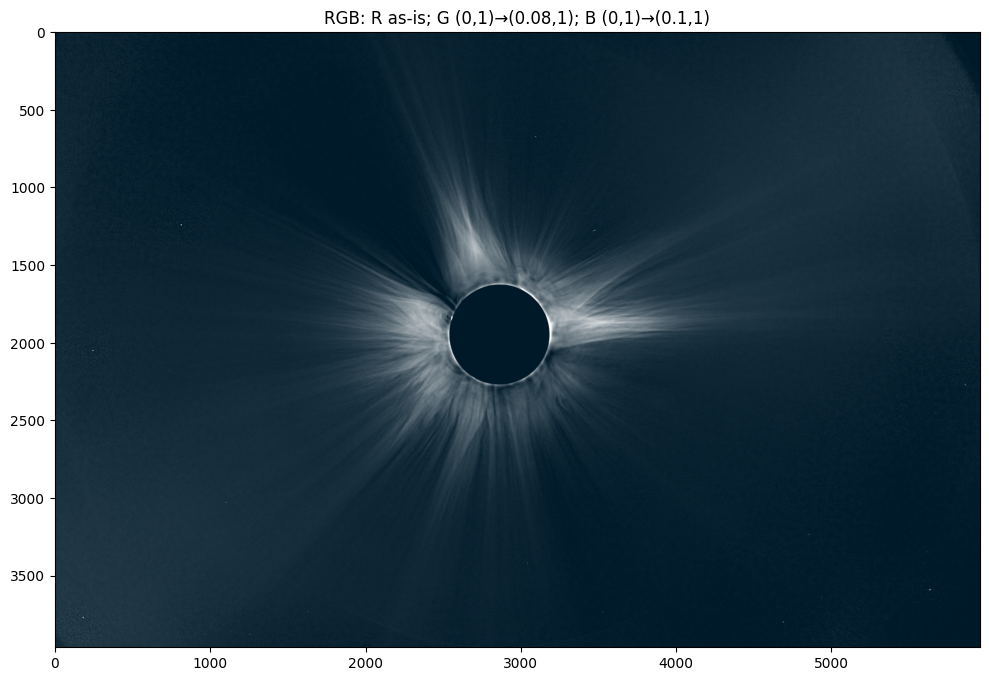

Saved /home/slavik/tmp/eda04_rgb_rescaled.png


In [17]:
# Grayscale -> RGB: R unchanged; G and B rescale black point (lift shadows)
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

gray = np.clip(sharpened_fft_diff.astype(np.float64), 0.0, 1.0)
R = gray
G = 0.10 + 0.90 * gray  # (0, 1) -> (0.10, 1)
B = 0.16 + 0.84 * gray  # (0, 1) -> (0.16, 1)
display_rgb = np.clip(np.stack([R, G, B], axis=-1), 0.0, 1.0)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(display_rgb)
ax.set_title("RGB: R as-is; G (0,1)→(0.08,1); B (0,1)→(0.1,1)")
plt.tight_layout()
plt.show()

out_png = Path(PKL_DIR) / "eda04_rgb_rescaled.png"
Image.fromarray((display_rgb * 255).round().clip(0, 255).astype(np.uint8)).save(out_png)
print(f"Saved {out_png}")

In [18]:
# Save radial params (mean_at per row_fraction, p3_at) for downstream use
import pickle
from pathlib import Path

out_path = Path(PKL_DIR) / "eda04_radial.pkl"
with open(out_path, "wb") as fd:
    pickle.dump({
        "row_fractions": row_fractions,
        "mean_at_list": mean_at_list,
        "p3_at": p3_at.cpu().numpy(),
        "moon_mask": moon_mask,
    }, fd)
print(f"Saved {out_path}")

Saved /home/slavik/tmp/eda04_radial.pkl
